# DES Y3 Observation Maps

Build weak lensing (metacal) and galaxy clustering (maglim) observation maps from the DES Y3 catalogs.

**Diagnostics:**
- `hp.mollview` plots with 10 arcmin Gaussian smoothing
- E-mode and B-mode convergence maps from the weak lensing shear catalog

In [10]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from msfm.utils import catalog, lensing, files

In [11]:
repo_dir = os.path.abspath("../../..")
conf_path = os.path.join(repo_dir, "configs/v16/default.yaml")
conf = files.load_config(conf_path)

n_side = conf["analysis"]["n_side"]
l_max = 3 * n_side - 1

# Official survey mask in RING ordering (same as catalog maps)
survey_mask = files.get_mask(conf, nest_out=False)
print(f"n_side={n_side}, l_max={l_max}, f_sky={survey_mask.mean():.4f}")

n_side=512, l_max=1535, f_sky=0.1013


## Build catalog maps

In [12]:
wl_gamma_map, wl_count_map = catalog.build_metacal_map_from_cat(conf)
# wl_gamma_map: (n_pix, n_z, 2) — gamma1/gamma2 per tomographic bin, RING ordering
# wl_count_map: (n_pix, n_z) — galaxy counts per bin
print(f"wl_gamma_map: {wl_gamma_map.shape}, wl_count_map: {wl_count_map.shape}")

26-05-13 14:35:38   catalog.py INF   Loaded metacal maps from cache 
wl_gamma_map: (3145728, 4, 2), wl_count_map: (3145728, 4)


In [13]:
gc_count_map = catalog.build_maglim_map_from_cat(conf)
# gc_count_map: (n_pix, n_z) — galaxy counts per tomographic bin, RING ordering
print(f"gc_count_map: {gc_count_map.shape}")

26-05-13 14:35:38   catalog.py INF   Loaded maglim map from cache 
gc_count_map: (3145728, 4)


## E- and B-mode decomposition

Apply the spherical Kaiser-Squires transformation to convert the observed shear $(\gamma_1, \gamma_2)$ into convergence $\kappa$.
Using `hp.map2alm` with `pol=True` on the $(0, \gamma_1, \gamma_2)$ triplet separates E- and B-mode alm coefficients in one pass.

In [14]:
_, gamma2kappa_fac, _ = lensing.get_kaiser_squires_factors(l_max)

n_z_wl = wl_gamma_map.shape[1]
kappa_E = np.zeros((hp.nside2npix(n_side), n_z_wl))
kappa_B = np.zeros((hp.nside2npix(n_side), n_z_wl))

for i in range(n_z_wl):
    g1 = wl_gamma_map[:, i, 0] * survey_mask
    g2 = wl_gamma_map[:, i, 1] * survey_mask
    _, alm_E, alm_B = hp.map2alm(
        [np.zeros_like(g1), g1, g2], pol=True, use_pixel_weights=True
    )
    kappa_E[:, i] = hp.alm2map(alm_E * gamma2kappa_fac, n_side, pol=False)
    kappa_B[:, i] = hp.alm2map(alm_B * gamma2kappa_fac, n_side, pol=False)
    print(f"Bin {i+1}: sigma(E) = {kappa_E[:, i].std():.4e}, sigma(B) = {kappa_B[:, i].std():.4e}")

Bin 1: sigma(E) = 8.8809e-03, sigma(B) = 8.8611e-03
Bin 2: sigma(E) = 9.5642e-03, sigma(B) = 9.5750e-03
Bin 3: sigma(E) = 9.5349e-03, sigma(B) = 9.5285e-03
Bin 4: sigma(E) = 1.1606e-02, sigma(B) = 1.1614e-02


## Visualization helpers

In [ ]:
/users/athomsen/dlss/repos/multiprobe-simulation-forward-model/dev/notebooks/desy3/figures

In [ ]:
# sigma_rad = np.radians(10 / 60)  # 10 arcmin
sigma_rad = np.radians(1)  # 1 degree

fig_dir = os.path.join(repo_dir, "dev/notebooks/desy3/figures")
os.makedirs(fig_dir, exist_ok=True)


def smooth_masked(map_in, mask):
    """Zero outside footprint before smoothing so the Gaussian kernel
    doesn't bleed signal from UNSEEN pixels, then mask for display."""
    m = map_in.copy().astype(float)
    m[~mask] = 0.0
    m = hp.smoothing(m, sigma=sigma_rad)
    m[~mask] = hp.UNSEEN
    return m

## Galaxy clustering maps (maglim)

/tmp/ipykernel_138957/1010661942.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


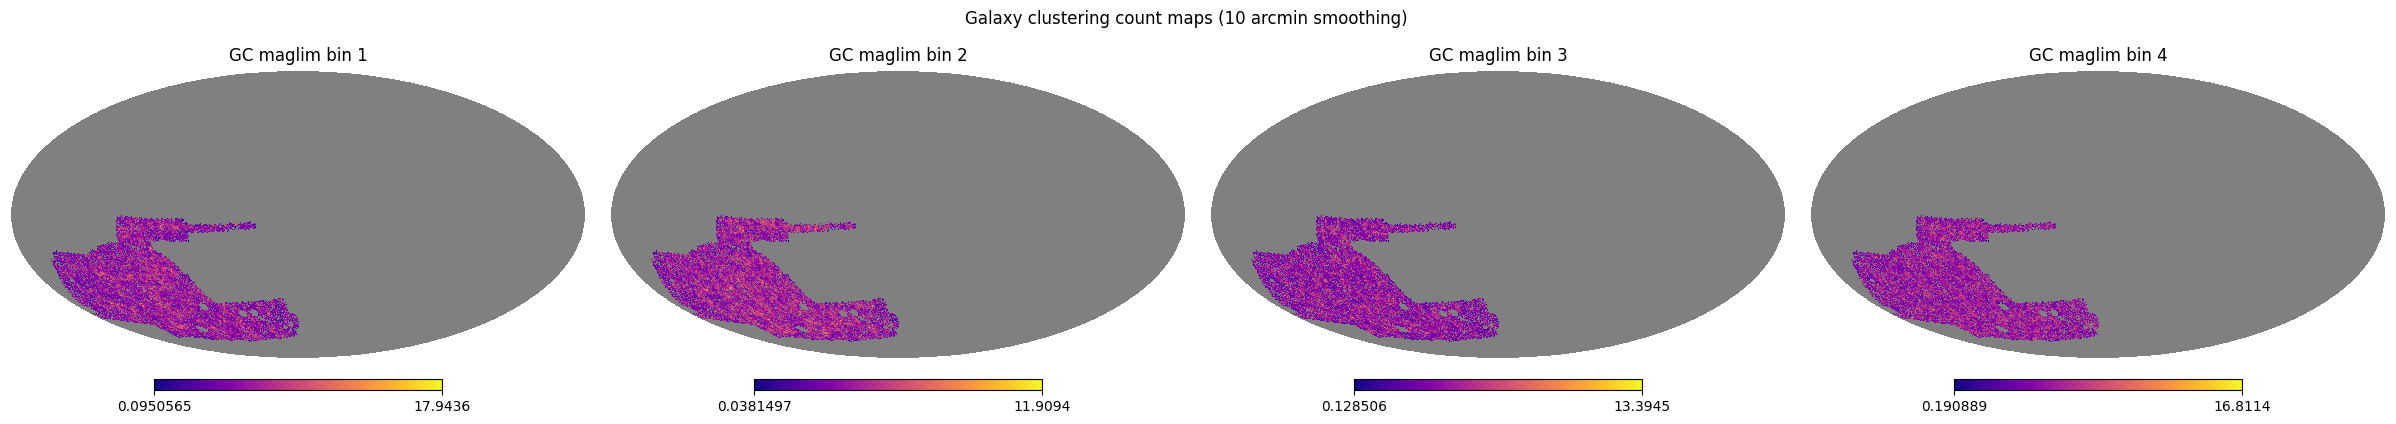

In [21]:
n_z_gc = gc_count_map.shape[1]

plt.figure(figsize=(6 * n_z_gc, 4))
for i in range(n_z_gc):
    m = smooth_masked(gc_count_map[:, i], survey_mask)
    hp.mollview(m, title=f"GC maglim bin {i+1}", sub=(1, n_z_gc, i + 1), notext=True, xsize=3000, cmap="plasma")
plt.suptitle("Galaxy clustering count maps (10 arcmin smoothing)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "gc_count_maps.png"), dpi=150, bbox_inches="tight")
plt.show()

## Weak lensing E-mode maps (metacal)

/tmp/ipykernel_138957/1564199899.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


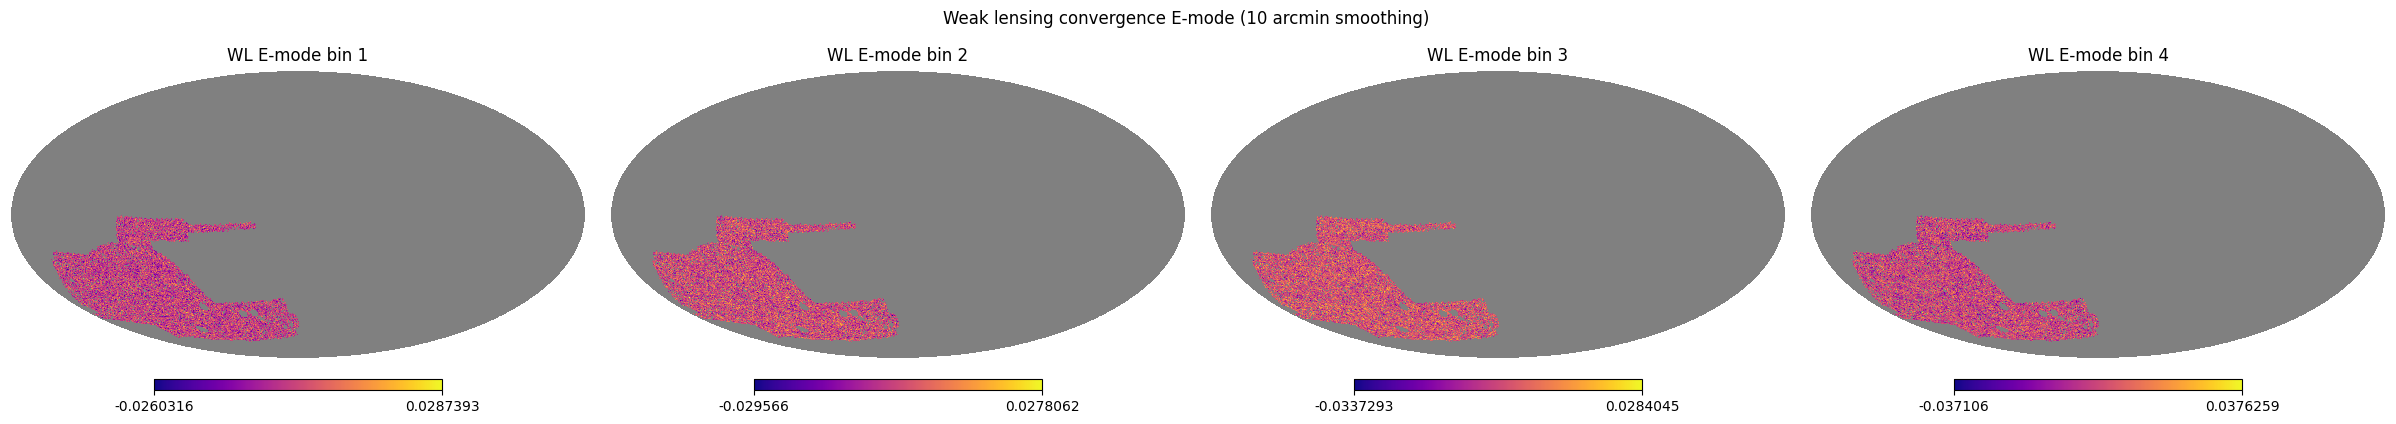

In [22]:
plt.figure(figsize=(6 * n_z_wl, 4))
for i in range(n_z_wl):
    m = smooth_masked(kappa_E[:, i], survey_mask)
    hp.mollview(m, title=f"WL E-mode bin {i+1}", sub=(1, n_z_wl, i + 1), notext=True, xsize=3000, cmap="plasma")
plt.suptitle("Weak lensing convergence E-mode (10 arcmin smoothing)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "wl_kappa_E_maps.png"), dpi=150, bbox_inches="tight")
plt.show()

## Weak lensing B-mode maps (metacal)

B-modes should be consistent with noise — much smaller amplitude than E-modes.

/tmp/ipykernel_138957/1041286832.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


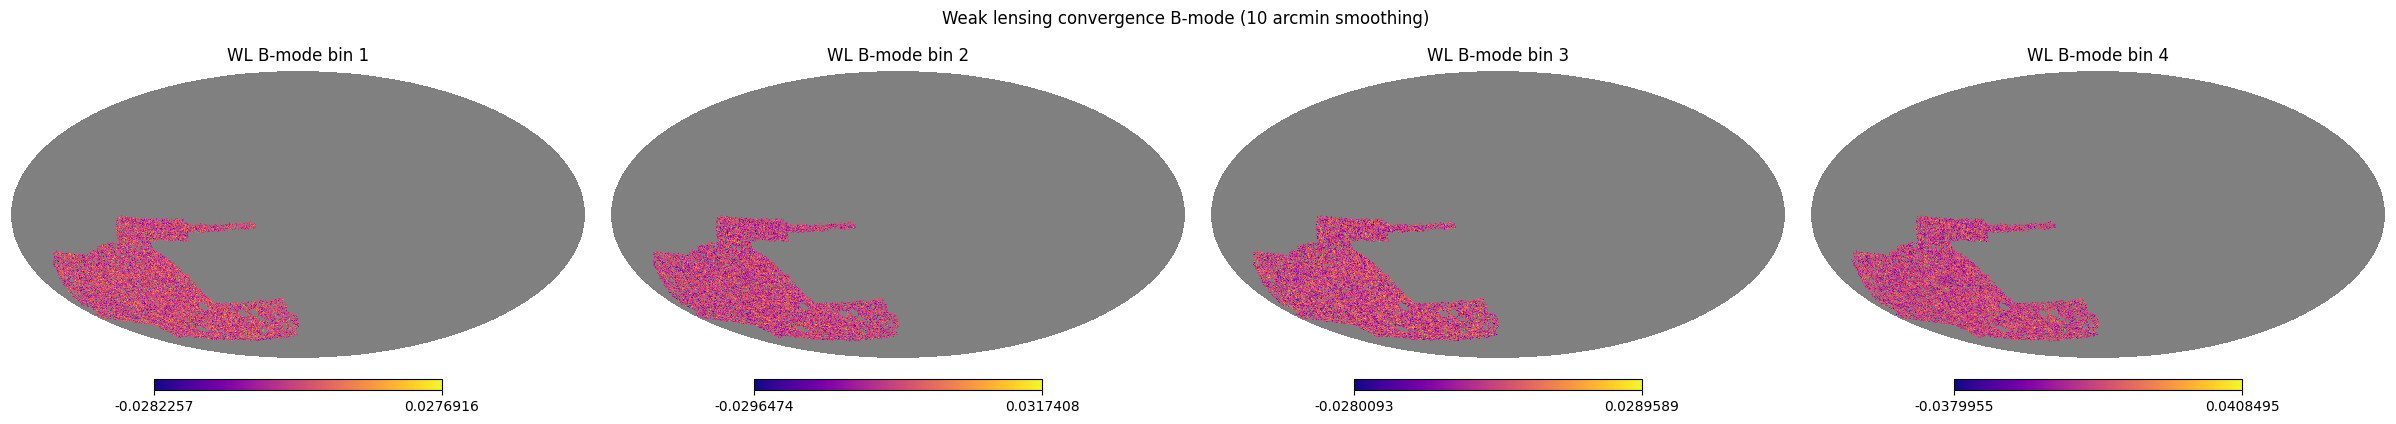

In [23]:
plt.figure(figsize=(6 * n_z_wl, 4))
for i in range(n_z_wl):
    m = smooth_masked(kappa_B[:, i], survey_mask)
    hp.mollview(m, title=f"WL B-mode bin {i+1}", sub=(1, n_z_wl, i + 1), notext=True, xsize=3000, cmap="plasma")
plt.suptitle("Weak lensing convergence B-mode (10 arcmin smoothing)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "wl_kappa_B_maps.png"), dpi=150, bbox_inches="tight")
plt.show()